# Traitement d'images: 
## en analyse non supervisée
## en analyse semi-supervisée

In [1]:
# === Data manipulation ===
import numpy as np
import pandas as pd

# === Visualisation ===
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# === Machine Learning===
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, adjusted_rand_score, f1_score, precision_recall_curve,confusion_matrix,roc_curve, average_precision_score, classification_report, auc
from sklearn.metrics import f1_score as sklearn_f1
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors

# === Computer Vision ===
import cv2


# === Deep Learning (TensorFlow / Keras) ===
import tensorflow as tf
keras = tf.keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.metrics import AUC, Precision, Recall, FalsePositives, FalseNegatives


import os
import random
import hashlib
from collections import defaultdict

print ("imports terminés")


imports terminés


## Analyse Exploratoire des données

In [2]:
print(os.listdir(r"data\mri_dataset_brain_cancer_oc"))

['avec_labels', "Jeu de Données d'Images Cérébrales pour la Détection de Tumeurs.txt", 'sans_label']


exploration visuelle

cv2, module Python de la bibliotheque OpenCV pour le traitement d'images

recheche d'images illisibles et verification des dimensions de tout le data set

In [3]:
dataset_path = "data/mri_dataset_brain_cancer_oc"
valid_ext = (".jpg", ".jpeg", ".png")

sizes = []
bad_images = []

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if not file.lower().endswith(valid_ext):
            continue

        img_path = os.path.join(root, file)

        img = cv2.imread(img_path)

        if img is None:
            bad_images.append(img_path)
            print("Image illisible :", img_path)
            continue

        sizes.append(img.shape)

print("\nNombre d'images illisibles :", len(bad_images))
print("Tailles uniques des images :", set(sizes))


Nombre d'images illisibles : 0
Tailles uniques des images : {(512, 512, 3)}


Vérification des doublons (par hashing, avec chunks pour economiser de la memoire)

hashing en sha256

In [4]:
dataset_path = r"data/mri_dataset_brain_cancer_oc"
valid_ext = (".png", ".jpg", ".jpeg")

hash_dict = defaultdict(list)

def get_hash(filepath):
    hasher = hashlib.sha256()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hasher.update(chunk)
    return hasher.hexdigest()


for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if not file.lower().endswith(valid_ext):
            continue

        path = os.path.join(root, file)

        file_hash = get_hash(path)

        hash_dict[file_hash].append(path)


duplicates = {h: p for h, p in hash_dict.items() if len(p) > 1}

print("Nombre de groupes de doublons :", len(duplicates))

Nombre de groupes de doublons : 90


recherche du chemin des doublons concernés

In [5]:
for h, paths in duplicates.items():
    print("\nDoublon détecté :")
    for p in paths:
        print(p)


Doublon détecté :
data/mri_dataset_brain_cancer_oc\avec_labels\cancer\11a7a426-4806-401e-98b2-b96e7094d1a6.jpg
data/mri_dataset_brain_cancer_oc\sans_label\f9466180-1e6b-4152-9176-6b4e2dc186ed.jpg

Doublon détecté :
data/mri_dataset_brain_cancer_oc\avec_labels\cancer\5af7f2cb-a82b-4635-865e-5b57dbc7a087.jpg
data/mri_dataset_brain_cancer_oc\sans_label\bd90cca9-a572-4464-b6fd-edb2af3e9a15.jpg

Doublon détecté :
data/mri_dataset_brain_cancer_oc\avec_labels\cancer\7e3f6acd-c9cc-440e-ba01-fedab0462fed.jpg
data/mri_dataset_brain_cancer_oc\sans_label\e9721e3a-e3c6-4a09-9b30-3c82b809069e.jpg

Doublon détecté :
data/mri_dataset_brain_cancer_oc\avec_labels\cancer\9ff6e310-b23a-4240-ac18-9fd99bd48e80.jpg
data/mri_dataset_brain_cancer_oc\sans_label\74486ecc-2beb-460d-89cb-50880e1a3daa.jpg

Doublon détecté :
data/mri_dataset_brain_cancer_oc\avec_labels\cancer\a8319ab8-471b-4d18-bb47-a377c4f9bd38.jpg
data/mri_dataset_brain_cancer_oc\sans_label\cf0cf298-45f4-4e43-a388-5a0d5f4b6095.jpg

Doublon détect

vérification visuelle des doublons (sur 3 groupes)

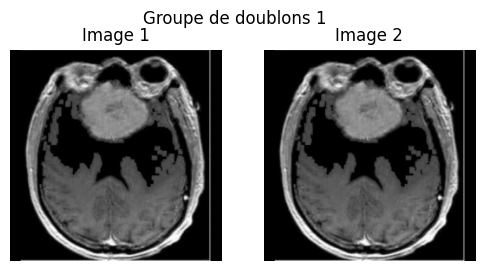

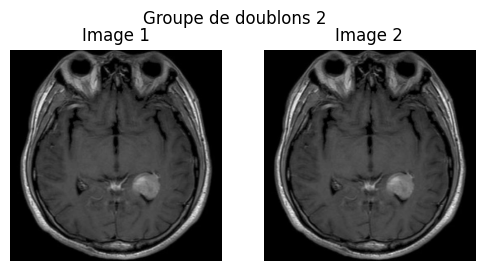

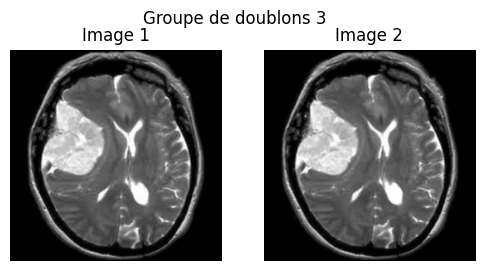

In [6]:
sample_duplicates = list(duplicates.items())[:3]

for i, (h, paths) in enumerate(sample_duplicates):

    n = len(paths)

    plt.figure(figsize=(3*n, 3))

    for j, path in enumerate(paths):

        img = cv2.imread(path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, n, j+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Image {j+1}")

    plt.suptitle(f"Groupe de doublons {i+1}")
    plt.show()

=>les images identiques prouvent l'existence de doublons

Suppression des doublons: 3 cas possibles:

1_Si un doublon existe entre avec_labels et sans_label: on garde l'image avec_label;

2_Si les doublons sont dans le même dossier (avec_labels): on garde la première image;

3_Si les doublons sont dans le même dossier (sans_label): on garde la première image.

In [7]:
deleted = 0

for paths in duplicates.values():

    labeled = [p for p in paths if "avec_labels" in p]
    unlabeled = [p for p in paths if "sans_label" in p]

    # CAS 1 : doublon entre labeled et unlabeled
    if len(labeled) > 0 and len(unlabeled) > 0:

        # garder la première image avec label
        keep = labeled[0]

        # supprimer toutes les unlabeled
        for p in unlabeled:
            os.remove(p)
            deleted += 1
            print("Supprimé (sans label doublon) :", p)

        # si plusieurs labeled, garder la première
        for p in labeled[1:]:
            os.remove(p)
            deleted += 1
            print("Supprimé (doublon labeled) :", p)

    # CAS 2 : uniquement labeled
    elif len(labeled) > 0:

        keep = labeled[0]

        for p in labeled[1:]:
            os.remove(p)
            deleted += 1
            print("Supprimé (doublon labeled) :", p)

    # CAS 3 : uniquement unlabeled
    else:

        keep = unlabeled[0]

        for p in unlabeled[1:]:
            os.remove(p)
            deleted += 1
            print("Supprimé (doublon unlabeled) :", p)

print("Total supprimé :", deleted)

Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc\sans_label\f9466180-1e6b-4152-9176-6b4e2dc186ed.jpg
Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc\sans_label\bd90cca9-a572-4464-b6fd-edb2af3e9a15.jpg
Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc\sans_label\e9721e3a-e3c6-4a09-9b30-3c82b809069e.jpg
Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc\sans_label\74486ecc-2beb-460d-89cb-50880e1a3daa.jpg
Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc\sans_label\cf0cf298-45f4-4e43-a388-5a0d5f4b6095.jpg
Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc\sans_label\6e0979a9-aef4-4745-bc30-8a507398da26.jpg
Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc\sans_label\3d09671b-9479-4ec9-a9cf-2934ad88657b.jpg
Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc\sans_label\647895dc-e736-4a30-bc1b-71c5b3065b17.jpg
Supprimé (sans label doublon) : data/mri_dataset_brain_cancer_oc

détection d’outliers (images très sombres-intensité à 0, ou toutes blanches-intensité à 255, totalement illisibles)

In [8]:
means = []

for cls in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, cls)

    if os.path.isdir(class_path):

        for img_name in os.listdir(class_path):

            img = cv2.imread(os.path.join(class_path, img_name))

            if img is not None:
                means.append(img.mean())

print("\nStatistiques intensité pixels :")
print("Min :", np.min(means))
print("Max :", np.max(means))
print("Mean :", np.mean(means))


Statistiques intensité pixels :
Min : 14.945938110351562
Max : 136.21646881103516
Mean : 51.60526270688171


Histogramme des intensités (détection d’outliers)

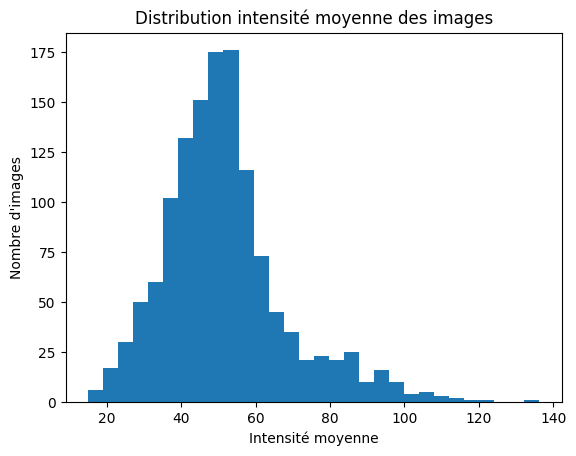

In [9]:
plt.hist(means, bins=30)
plt.title("Distribution intensité moyenne des images")
plt.xlabel("Intensité moyenne")
plt.ylabel("Nombre d'images")
plt.show()

=>on conserve toutes les images: pas d'images noires (0) ni blanches (255)

on fera une normalisation plus tard sur les images pour diminuer l'intensité

Explorer les données labelisées (distribution des classes)

In [3]:
base_path = "data/mri_dataset_brain_cancer_oc/avec_labels"

for cls in os.listdir(base_path):  
    class_path = os.path.join(base_path, cls)
    if os.path.isdir(class_path):
        print(cls, ":", len(os.listdir(class_path)), "images")

cancer : 50 images
normal : 49 images


tailles des images sur **données labelisées**

In [4]:
base_path = "data/mri_dataset_brain_cancer_oc/avec_labels"
valid_extensions = (".jpg", ".jpeg", ".png")

sizes = []

for cls in os.listdir(base_path):
    class_path = os.path.join(base_path, cls)
    
    if not os.path.isdir(class_path):
        continue
    
    images = [f for f in os.listdir(class_path) if f.lower().endswith(valid_extensions)]
    
    for img_name in images[:]:
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        
        if img is None:
            continue
        
        sizes.append(img.shape)

print("Tailles uniques trouvées :", set(sizes))

Tailles uniques trouvées : {(512, 512, 3)}


Affichage de quelques images labelisées par classe 

les pixels utilisent 3 canaux de couleur RGB

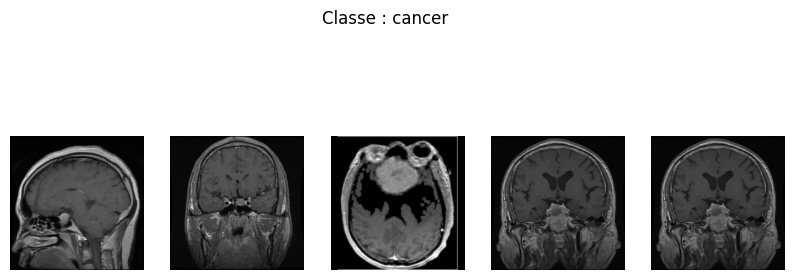

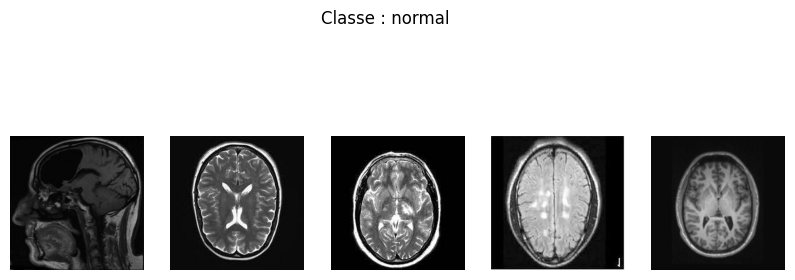

In [5]:
for cls in os.listdir(base_path):
    class_path = os.path.join(base_path, cls)
    
    if not os.path.isdir(class_path):
        continue
    
    images = [f for f in os.listdir(class_path) if f.lower().endswith(valid_extensions)]
    
    plt.figure(figsize=(10, 4))
    
    for i in range(5):  
        img_name = random.choice(images)
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        
        if img is None:
            continue
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.axis("off")
    
    plt.suptitle(f"Classe : {cls}")
    plt.show()

Resize en taille standard pour ResNet : 224x224 (ResNet)

In [6]:
img = cv2.imread(img_path)
img_resized = cv2.resize(img, (224, 224))

print("Nouvelle taille :", img_resized.shape)

Nouvelle taille : (224, 224, 3)


definition de X et y à partir des images labelisées

In [7]:
base_path = "data/mri_dataset_brain_cancer_oc/avec_labels"
img_size = 224

# Mapping : normal = 0, cancer = 1
CLASS_MAP = {"normal": 0, "cancer": 1}

X = []
y = []

classes = sorted(os.listdir(base_path))
print("Classes détectées :", classes)

for cls in classes:
    class_path = os.path.join(base_path, cls)

    if not os.path.isdir(class_path):
        continue

    label = CLASS_MAP.get(cls)
    if label is None:
        print(f"Classe inconnue ignorée : {cls}")
        continue

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (img_size, img_size))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        X.append(img)
        y.append(label)

Classes détectées : ['cancer', 'normal']


50 images "cancer" et 49 images "normal"

X, les images et y, les labels (0,1)

FN = prédit 0 (normal) alors que c'est 1 (cancer): cancer manqué (le plus critique)

FP = prédit 1 (cancer) alors que c'est 0 (normal): fausse alerte

normalisation en [0, 1] des pixels (de 0=noir à 255=blanc) pour stabiliser le modele

on évite l'explosion des gradients

In [8]:
X = np.array(X, dtype="float32") / 255.0   
y = np.array(y)
print(f"Distribution : {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"Dataset : {X.shape}, Labels : {y.shape}")

Distribution : {np.int64(0): np.int64(49), np.int64(1): np.int64(50)}
Dataset : (99, 224, 224, 3), Labels : (99,)


In [9]:
print("Mapping utilisé :", CLASS_MAP)
print("Labels uniques :", set(y))

Mapping utilisé : {'normal': 0, 'cancer': 1}
Labels uniques : {np.int64(0), np.int64(1)}


# analyse non supervisée

on va regarder si les images se partagent bien en 2 groupes (normal devrait etre séparé de cancer)

transformation des images en vecteur

In [10]:
X_features = X.reshape(X.shape[0], -1) # 1 image devient 1 ligne; 

print(X_features.shape)

(99, 150528)


Sans ResNet, on reste en pixels bruts: ARI négatifs et aucun clustering visible

raison: 150 000 pixels bruts pour seulement 99 images=>cluster sur pixels: trop de bruit

=>solution: utiliser ResNet50 pré-entraîné, SANS la tête de classification, sans la dernière couche

ResNet(50) donne une image en 2048 valeurs

=>=> cluster sur features

In [11]:
base_model = ResNet50(
    weights="imagenet",   # poids pré-entraînés sur ImageNet
    include_top=False,    # on retire la dernière couche Dense de classification (inutile=classe imags en 1000 categories)
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # on ne réentraîne pas ResNet, au contraire, on utilise tout ce qu'il a déjà appris

Extraction des features

In [12]:
feature_extractor = keras.Model(
    inputs=base_model.input,
    outputs=base_model.output # sortie avant la couche Dense pour les features
)

X_features_resnet = feature_extractor.predict(X)              
X_features_resnet = X_features_resnet.reshape(X.shape[0], -1) 
print("Features shape :", X_features_resnet.shape)

4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step
Features shape : (99, 100352)


Standardisation des features avant réduction de dimension et clustering

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features_resnet)

Réduction de dimension avec PCA

In [14]:
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)
print(f"Composantes retenues : {pca.n_components_}")
print(f"Variance expliquée : {pca.explained_variance_ratio_.sum()*100:.1f}%")

(99, 50)
Composantes retenues : 50
Variance expliquée : 94.2%


Visualisation avec t-SNE en 2D

perplexity=30: on regarde les 30 voisins de chaque point

In [15]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42) # on fixe les positions aleatoires
X_tsne = tsne.fit_transform(X_pca)

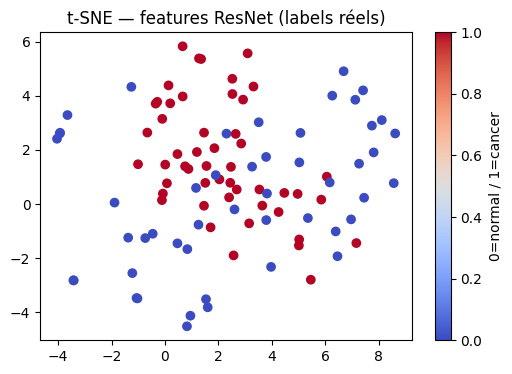

In [16]:
plt.figure(figsize=(6,4))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap="coolwarm")
plt.title("t-SNE — features ResNet (labels réels)")
plt.colorbar(label="0=normal / 1=cancer")
plt.show()

Clustering avec K-Means

distance euclidienne

baisser l'inertie (la somme des distances entre chaque point et son centre de cluster)

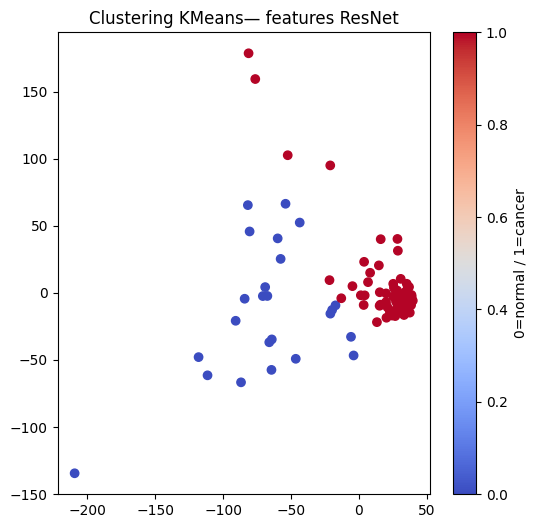

In [17]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters_kmeans = kmeans.fit_predict(X_pca)
plt.figure(figsize=(6,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_kmeans, cmap="coolwarm")
plt.title("Clustering KMeans— features ResNet")
plt.colorbar(label="0=normal / 1=cancer")
plt.show()

Score ARI (Adjusted Rand Index)
comparaison clusters trouvés vs labels réels

ARI par K‑Means

In [18]:
ari_kmeans = adjusted_rand_score(y, clusters_kmeans)
print(f"ARI KMeans : {ari_kmeans:.4f}")

ARI KMeans : 0.1332


Clustering avec DBSCAN

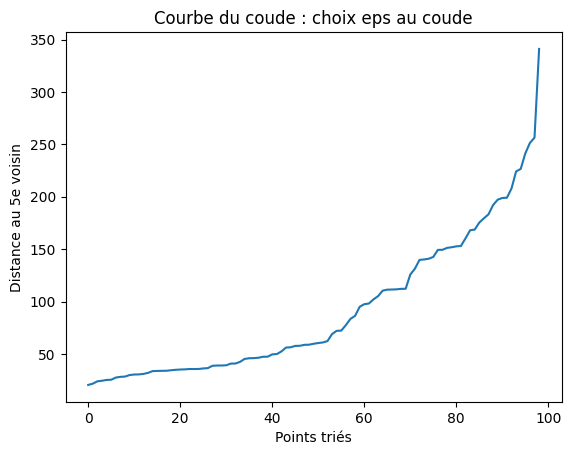

In [19]:
nn = NearestNeighbors(n_neighbors=5) # nb minimal de voisins dans un rayon epsilon
nn.fit(X_pca)
distances, _ = nn.kneighbors(X_pca)
distances = np.sort(distances[:, -1])

plt.plot(distances)
plt.title("Courbe du coude : choix eps au coude")
plt.xlabel("Points triés")
plt.ylabel("Distance au 5e voisin")
plt.show()

In [20]:
dbscan = DBSCAN(eps=120, min_samples=3)  # on choisit epsilon selon le coude
clusters_db = dbscan.fit_predict(X_pca)

print("Clusters DBSCAN uniques :", np.unique(clusters_db))


Clusters DBSCAN uniques : [-1  0]


graphique de DBSSAN 

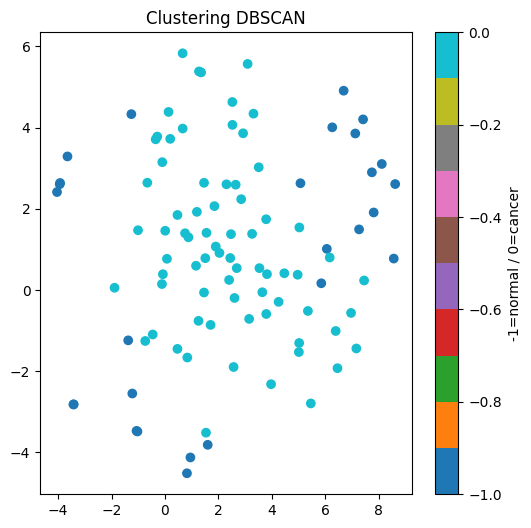

In [21]:
dbscan = DBSCAN(eps=120, min_samples=5)
clusters_db = dbscan.fit_predict(X_pca)

plt.figure(figsize=(6,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=clusters_db, cmap="tab10")
plt.colorbar(label="-1=normal / 0=cancer")
plt.title("Clustering DBSCAN")

plt.show()

In [22]:
ari_dbscan = adjusted_rand_score(y, clusters_db)

print("ARI DBSCAN:", ari_dbscan)

ARI DBSCAN: 0.21904690656093365


=>on va tester AgglomerativeClustering pour comparer:

ARI Agglomératif : 0.2800


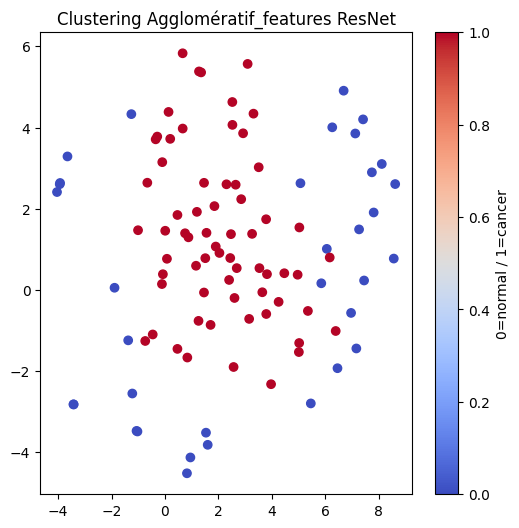

In [23]:
agglo = AgglomerativeClustering(n_clusters=2)
clusters_agglo = agglo.fit_predict(X_pca)

ari_agglo = adjusted_rand_score(y, clusters_agglo)
print(f"ARI Agglomératif : {ari_agglo:.4f}")

plt.figure(figsize=(6,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=clusters_agglo, cmap="coolwarm")
plt.title("Clustering Agglomératif_features ResNet")
plt.colorbar(label="0=normal / 1=cancer")
plt.show()

=>on teste GMM, modèle plus nuancé avec probabilité d'appartenance de classes:

ARI GMM : 0.2188


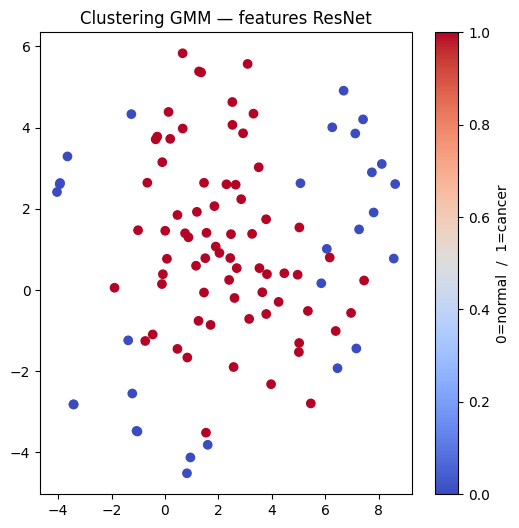

In [24]:
gmm = GaussianMixture(
    n_components=2,
    covariance_type="diag",    # diagonale (1 valeur par dimension) pour simplifier car seulement 99 images
    reg_covar=1e-3, # régularisation, ajout d'une valeur sur la diagonale de la matrice (pour éviter matrices singulières)
    random_state=42
)

# en float64 plutôt que float32 (on passe de 7 à 15 chiffres significatifs) 
# avec Gauss, matrices de covariance nécessitent une grande précision numérique
X_pca_64 = X_pca.astype("float64") 

gmm.fit(X_pca_64) # étape 1 : apprentissage
clusters_gmm = gmm.predict(X_pca_64) # étape 2 : assignation des clusters.GMM utilise .predict()

ari_gmm = adjusted_rand_score(y, clusters_gmm)
print(f"ARI GMM : {ari_gmm:.4f}")

plt.figure(figsize=(6,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=clusters_gmm, cmap="coolwarm")
plt.colorbar(label="0=normal  /  1=cancer")
plt.title("Clustering GMM — features ResNet")
plt.show()

GMM donne aussi les probabilités d'appartenance à chaque cluster

In [25]:
proba_gmm = gmm.predict_proba(X_pca)  # shape (99, 2)

# Probabilité que chaque image soit dans le cluster cancer
print("Probabilités (99 images):")
for i in range(99):
    print(f"  image {i} → cluster 0: {proba_gmm[i,0]:.2f} | cluster 1: {proba_gmm[i,1]:.2f}")

# Images ambiguës (GMM incertain)
ambigues = np.where((proba_gmm[:,0] > 0.4) & (proba_gmm[:,0] < 0.6))[0]
print(f"\nImages ambiguës (GMM incertain) : {len(ambigues)}")

Probabilités (99 images):
  image 0 → cluster 0: 0.00 | cluster 1: 1.00
  image 1 → cluster 0: 0.00 | cluster 1: 1.00
  image 2 → cluster 0: 0.00 | cluster 1: 1.00
  image 3 → cluster 0: 1.00 | cluster 1: 0.00
  image 4 → cluster 0: 0.00 | cluster 1: 1.00
  image 5 → cluster 0: 0.00 | cluster 1: 1.00
  image 6 → cluster 0: 0.00 | cluster 1: 1.00
  image 7 → cluster 0: 0.00 | cluster 1: 1.00
  image 8 → cluster 0: 0.00 | cluster 1: 1.00
  image 9 → cluster 0: 0.00 | cluster 1: 1.00
  image 10 → cluster 0: 0.00 | cluster 1: 1.00
  image 11 → cluster 0: 0.00 | cluster 1: 1.00
  image 12 → cluster 0: 0.00 | cluster 1: 1.00
  image 13 → cluster 0: 0.00 | cluster 1: 1.00
  image 14 → cluster 0: 0.00 | cluster 1: 1.00
  image 15 → cluster 0: 0.00 | cluster 1: 1.00
  image 16 → cluster 0: 0.00 | cluster 1: 1.00
  image 17 → cluster 0: 0.00 | cluster 1: 1.00
  image 18 → cluster 0: 0.00 | cluster 1: 1.00
  image 19 → cluster 0: 0.00 | cluster 1: 1.00
  image 20 → cluster 0: 0.00 | cluster 1: 1.

In [26]:
print("\n Comparaison clustering ")
print(f"ARI KMeans       : {ari_kmeans:.4f}")
print(f"ARI GMM          : {ari_gmm:.4f}")
print(f"ARI DBSCAN       : {ari_dbscan:.4f} ")
print(f"ARI Agglomératif : {ari_agglo:.4f}")



 Comparaison clustering 
ARI KMeans       : 0.1332
ARI GMM          : 0.2188
ARI DBSCAN       : 0.2190 
ARI Agglomératif : 0.2800


# analyse semi supervisee:

SPLIT TRAIN_TEST 

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train :", X_train.shape)
print("Test :", X_test.shape)

num_classes = len(classes)
print("Nombre de classes :", num_classes)

Train : (79, 224, 224, 3)
Test : (20, 224, 224, 3)
Nombre de classes : 2


# CNN 

metriques

In [28]:
metrics_auc, metrics_acc, metrics_f1, metrics_loss = [], [], [] , []
 
 
def plot_metrics():
    """Trace l'évolution des AUC/Accuracy/F1 si des valeurs sont disponibles."""
    if len(metrics_auc) == 0:
        print("Aucune métrique enregistrée pour le moment.")
        return
    steps = range(1, len(metrics_auc) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(steps, metrics_auc, label='AUC')
    plt.plot(steps, metrics_acc, label='Accuracy')
    plt.plot(steps, metrics_f1, label='F1 (macro)')
    plt.plot(steps, metrics_loss, label='loss')
    plt.xlabel('Étape / Itération')
    plt.ylabel('Score')
    plt.title("Évolution des métriques")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
 

In [ ]:
def train_and_evaluate(model, X_train_data, y_train_data, X_test_data, y_test_data,
                       epochs=10, batch_size=32, datagen=None):
    """
    Entraîne et évalue un modèle Keras. Retourne (auc, acc, f1, loss).
    Si des listes globales metrics_auc/metrics_acc/metrics_f1 existent/metrics_loss, y ajoute les scores.
 
    Paramètres
    ----------
    model       : modèle Keras compilé
    X_train_data, y_train_data : données d'entraînement
    X_test_data,  y_test_data  : données de test
    epochs      : nombre d'epochs
    batch_size  : taille des batchs
    datagen     : ImageDataGenerator optionnel(data augmentation)
    """
 
    # --- Entraînement ---
    if datagen is not None:
        # avec augmentation - transfert learning
        model.fit(
            datagen.flow(X_train_data, y_train_data, batch_size=batch_size),
            epochs=epochs,
            validation_data=(X_test_data, y_test_data),
            verbose=1
        )
    else:
        # baseline CNN ou boucle SSL (sans augmentation)
        model.fit(
            X_train_data, y_train_data,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.1,
            verbose=1
        )
 
    # --- Évaluation Keras---
    loss, accuracy, roc_auc, precision, recall, fp, fn = model.evaluate(
        X_test_data, y_test_data, verbose=0
    )

    # F1 macro manuel pour Keras() + binairisation des probas à 0.5
    y_proba = model.predict(X_test_data, verbose=0).flatten()
    y_pred  = (y_proba > 0.5).astype(int)
    f1      = sklearn_f1(y_test_data.astype(int), y_pred, average='macro')
 
    # Affichage
    print(f'AUC: {roc_auc:.3f}, Accuracy: {accuracy:.3f}, F1: {f1:.3f}')
    print(f"Loss              : {loss:.4f}")
    print(f"Precision         : {precision:.4f}")
    print(f"Recall            : {recall:.4f}")
    print(f"Faux Positifs     : {int(fp)}")
    print(f"Faux Négatifs     : {int(fn)}")
 
    # Mise à jour des métriques globales (on passe si ces listes n'existent pas)
    try:
        metrics_auc.append(roc_auc)
        metrics_acc.append(accuracy)
        metrics_f1.append(f1)
        metrics_loss.append(loss)
    except NameError:
        pass
 
    return (roc_auc, accuracy, f1, loss)

modele de base CNN : 
choix sur Keras()

Conv détecte les formes (simples, complexes) = apprentissage des paramètres; nb de filtres augmente au fur et à mesure  
Pool: reduction des tailles et économie de mémoire (optimisation)  
Dense: va retourner une proba selon le seuil que l'on a choisi
Dropout: désactive une partie des neurones pdt entraînement (ici 50%) pour éviter overfitting  
ReLu: F° activation du CNN pour apprentissage formes complexes, max(0,x) => sortie >0=neurone activé
sortie sigmoïde=proba cancer

In [30]:
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)),
    layers.MaxPooling2D(2, 2),
 
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),
 
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),
 
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
 
    layers.Dense(1, activation="sigmoid")
])
 
model.compile(
    optimizer="adam",
    loss="binary_crossentropy", 
    metrics=[
        "accuracy",
        AUC(name="roc_auc"),
        Precision(name="precision"),
        Recall(name="recall"),
        FalsePositives(name="fp"),
        FalseNegatives(name="fn")
    ]
)
# compatibilité avec Keras en binary_crossentropy (vs numpy en int64)
y_train = y_train.astype("float32")
y_test  = y_test.astype("float32")
 
# --- Entraînement + évaluation du baseline via train_and_evaluate ---
print("Entraînement modèle de base_images labellisées")
baseline_metrics = train_and_evaluate(model, X_train, y_train, X_test, y_test,
                                      epochs=10, batch_size=32)
 
model_base = model

c:\Users\chris\traitement_images_semi_supervisées\venv312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entraînement modèle de base_images labellisées
Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.5775 - fn: 14.0000 - fp: 16.0000 - loss: 0.6827 - precision: 0.6000 - recall: 0.6316 - roc_auc: 0.6240 - val_accuracy: 0.7500 - val_fn: 2.0000 - val_fp: 0.0000e+00 - val_loss: 0.5343 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.8333
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 595ms/step - accuracy: 0.5352 - fn: 18.0000 - fp: 15.0000 - loss: 0.9706 - precision: 0.5714 - recall: 0.5263 - roc_auc: 0.5754 - val_accuracy: 0.2500 - val_fn: 0.0000e+00 - val_fp: 6.0000 - val_loss: 0.8695 - val_precision: 0.2500 - val_recall: 1.0000 - val_roc_auc: 0.2500
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 755ms/step - accuracy: 0.6901 - fn: 4.0000 - fp: 18.0000 - loss: 0.6630 - precision: 0.6538 - recall: 0.8947 - roc_auc: 0.6722 - val_accuracy: 0.7500 - val_fn: 1.0000 - val_fp: 1.0000 - val_loss: 0.6206 - val_precision: 0.5000 - val_recall: 0.5000 - val_roc_auc: 0.8333
Epoch 4/10


matrice de confusion (baseline) sur les vrais labels

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


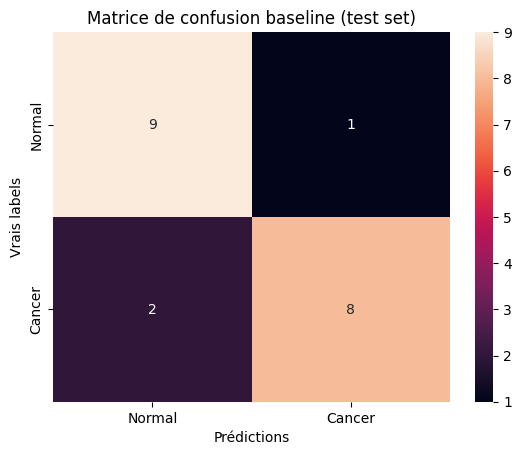

In [31]:
y_proba_base = model_base.predict(X_test).flatten()
y_pred = (y_proba_base > 0.5).astype(int).flatten()
 
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Normal", "Cancer"],
            yticklabels=["Normal", "Cancer"])
plt.title("Matrice de confusion baseline (test set)")
plt.xlabel("Prédictions")
plt.ylabel("Vrais labels")
plt.show()

courbe precision rappel

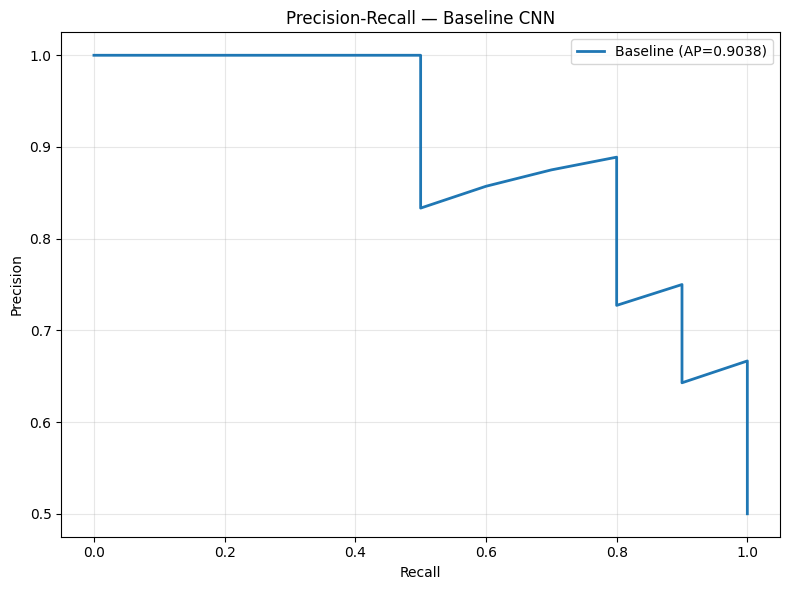

In [32]:
precision_base, recall_base, _ = precision_recall_curve(y_test, y_proba_base)
ap_base = average_precision_score(y_test, y_proba_base)
 
plt.figure(figsize=(8, 6))
plt.plot(recall_base, precision_base, label=f"Baseline (AP={ap_base:.4f})", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall — Baseline CNN")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

distribution des probabilités  
=>choix du seuil des images sans label les plus confiantes pour notre modele

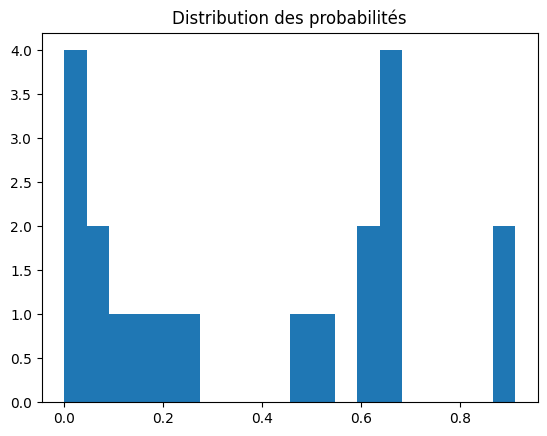

In [33]:
plt.hist(y_proba_base, bins=20)
plt.title("Distribution des probabilités")
plt.show()

data augmentation: multiplie artificiellement les données

In [34]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

TRANSFERT LEARNING de ResNet

In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False, # on ne cherche pas à classer images en catégories
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # couches ResNet gelées, on utilise le modele déjà entraîné.
 
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"), # apprentissage formes complexes
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])
 
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        AUC(name="roc_auc"),
        Precision(name="precision"),
        Recall(name="recall"),
        FalsePositives(name="fp"),
        FalseNegatives(name="fn")
    ]
)

print("Entraînement Transfer Learning (ResNet50 + augmentation)...")

tl_metrics = train_and_evaluate(model, X_train, y_train, X_test, y_test,
                                epochs=10, batch_size=8, datagen=datagen)

Entraînement Transfer Learning (ResNet50 + augmentation)...
Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.5190 - fn: 26.0000 - fp: 12.0000 - loss: 0.8488 - precision: 0.5385 - recall: 0.3500 - roc_auc: 0.4628 - val_accuracy: 0.7500 - val_fn: 1.0000 - val_fp: 4.0000 - val_loss: 0.6339 - val_precision: 0.6923 - val_recall: 0.9000 - val_roc_auc: 0.8800
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 769ms/step - accuracy: 0.5316 - fn: 9.0000 - fp: 28.0000 - loss: 0.7346 - precision: 0.5254 - recall: 0.7750 - roc_auc: 0.5728 - val_accuracy: 0.7000 - val_fn: 0.0000e+00 - val_fp: 6.0000 - val_loss: 0.6036 - val_precision: 0.6250 - val_recall: 1.0000 - val_roc_auc: 0.8850
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 712ms/step - accuracy: 0.5696 - fn: 21.0000 - fp: 13.0000 - loss: 0.6650 - precision: 0.5938 - recall: 0.4750 - roc_auc: 0.6494 - val_accuracy: 0.6500 - val_fn: 6.0000 - val_fp: 1.0000 - val_loss: 0.5894 - val_precision: 0.8000 - val_recall: 0.4000 - val_roc_auc: 0.8800
Epo

chargement des images sans label

In [36]:
unlabeled_path = "data/mri_dataset_brain_cancer_oc/sans_label"
X_unlabeled = []
 
for img_name in os.listdir(unlabeled_path):
    img_path = os.path.join(unlabeled_path, img_name)
    img = cv2.imread(img_path)
 
    if img is None:
        continue
 
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    X_unlabeled.append(img)
 
X_unlabeled = np.array(X_unlabeled, dtype="float32") / 255.0
print("Unlabeled shape:", X_unlabeled.shape)

Unlabeled shape: (1311, 224, 224, 3)


generation des pseudo labels  
peu de labels-> entraînement modele-> predictions sur données non labelisées  
->on garde celles dont le modele est sûr-> ajout au train set  
N.B: X_unlabeled_current change à chaque itération de la boucle.

In [ ]:
def get_pseudo_labels(model, X_unlabeled_current, unlabeled_indices, threshold=0.90):
    """
    Génère des pseudo-labels pour les images où le modèle est confiant.
    Retourne les indices globaux retenus et leurs pseudo-labels.
    """
    # prediction pour chaque image non labelisée (proba= sortie sigmoïde)
    pseudo_probs = model.predict(X_unlabeled_current, verbose=0).flatten()

    #on ne garde que les images les + confiantes
    confident_mask         = (pseudo_probs > threshold) | (pseudo_probs < (1 - threshold))

    # tableau en 1 seul argument ([0]=en 1D) des indices locaux relatifs à X_unlabeled_current qd mask=True
    selected_indices_local = np.where(confident_mask)[0]

    # vrais indices globaux (images non labelisées) du data set pour ne pas reproposer ces images lors des itérations SSL
    # on retire les images du pool non labelisé, ajout au train set avec leur pseudo-label
    selected_global_indices = [unlabeled_indices[i] for i in selected_indices_local]
    
    # images retenues sont binarisées à 0.5 (proba >0.9 alors label 1))
    pseudo_labels           = (pseudo_probs[selected_indices_local] > 0.5).astype("float32").tolist()

    print(f"Nombre d'images confiantes (> {threshold:.2f}) : {len(selected_global_indices)}")
    return selected_global_indices, pseudo_labels

pseudo labels  
on ne garde que les images où le modèle est confiant

In [ ]:
THRESHOLD = 0.90
pseudo_probs = model.predict(X_unlabeled, verbose=0).flatten()

mask     = (pseudo_probs > THRESHOLD) | (pseudo_probs < (1 - THRESHOLD))
# On applique le masque directement sur les images pour ne garder que celles où le modèle est confiant
X_pseudo = X_unlabeled[mask]
# Génération des pseudo-labels
y_pseudo = (pseudo_probs[mask] > 0.5).astype("float32")

print(f"Pseudo labels confiants détectés par le Transfer Learning : {len(y_pseudo)}")

Pseudo labels confiants détectés par le Transfer Learning : 42


re initialisation du modele avant la boucle (conforme au cours "initiez-vous-l-apprentissage-semi-supervisé")

In [39]:
ssl_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
ssl_base.trainable = False
 
ssl_model = keras.Sequential([
    ssl_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])
 
ssl_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        AUC(name="roc_auc"),
        Precision(name="precision"),
        Recall(name="recall"),
        FalsePositives(name="fp"),
        FalseNegatives(name="fn")
    ]
)
 
print("Modèle ssl_model réinitialisé pour la boucle semi-supervisée.")

Modèle ssl_model réinitialisé pour la boucle semi-supervisée.


DATASET GLOBAL

fusion de données labellisées et non labellisées.  
on va contruire X_full = X_train + X_unlabeled  
X_full est un tableau avec des images labelisées et des images non labelisées  
y_full est un tableau avec des labels 0,1 et -1 (-1=unlabeled, images sans label réel, sans label initial)
y_full est de m^me taille que X_full puisque (len(X_unlabeled))

In [40]:
X_full = np.concatenate([X_train, X_unlabeled])
y_full = np.concatenate([y_train, np.full(len(X_unlabeled), -1)])

on garde une trace de X_full:positions des images labelisées et positions des images non-labelisées  
à chaque itération, X_full labelisé et X_full non labelisé (avec images confiantes)

In [41]:
current_labeled_indices = list(range(len(X_train))) # positions des labellisés
unlabeled_indices       = list(range(len(X_train), len(X_full))) # positions des non labellisés

BOUCLE SEMI-SUPERVISÉE  
La fonction itère n fois en enrichissant progressivement le set d'entraînement avec des pseudo-labels.

In [ ]:
def semi_supervised_training(
    model,
    X_full,
    y_full,
    current_labeled_indices,
    unlabeled_indices,
    X_test,
    y_test,
    confidence_threshold=0.90,
    iterations=5,
    batch_size=8,
    epochs=5
):
    for iteration in range(iterations):
        print(f"\n--- Itération {iteration+1} ---")

        # 1. Dataset courant
        # extraction des images actuellement labellisées (vrais labels + pseudo-labels des itérations précédentes) + on entraîne le modèle
        X_labeled = X_full[current_labeled_indices]
        y_labeled = y_full[current_labeled_indices]

        print(f"Entraînement sur {len(X_labeled)} images...")

        # appel à train_and_evaluate
        # modele SSL maj à chq iter, images courantes avec vrais labels et pseudos-labels accumulés, labels (0,1 et pas de -1: ne sont pas choisis)
        # N.B: la fonction retourne un tuple en 4 métriques à chaque iter
        # X_labeled grandit à chaque iter
        # on change le nom des metriques pour les comparer avec celles de la baseline et celles du transfert learning
        pseudo_label_auc, pseudo_label_acc, pseudo_label_f1, pseudo_label_loss = train_and_evaluate(
            model, X_labeled, y_labeled, X_test, y_test,
            epochs=epochs, batch_size=batch_size
        )

        # 2. Génération pseudo-labels
        # si plus d'images non labellisées ou aucun pseudo-label confiant, alors break.
        # sinon, get_pseudo_labels() retourne les indices globaux et labels des images les + confiantes
        print("Génération de pseudo-labels...")

        if len(unlabeled_indices) == 0:
            print("Plus d'images non labellisées, on arrête là !")
            break
        
        # prédiction uniquement sur les images encore non labellisées, pas sur tout le dataset
        # à chq itération, unlabeled_indices diminue car on retire les images pseudo-labellisées    
        X_unlabeled_current = X_full[unlabeled_indices]
        pseudo_indices, pseudo_labels = get_pseudo_labels(
            model, X_unlabeled_current, unlabeled_indices,
            threshold=confidence_threshold
        )
        print(f"{len(pseudo_indices)} nouveaux pseudo-labels ajoutés.")

        if len(pseudo_indices) == 0:
            print("Plus de pseudo-labels trouvés, on arrête là !")
            break

        # 3. Mise à jour in-place de y_full
        new_indices = []
        for idx, label in zip(pseudo_indices, pseudo_labels):
            if idx not in current_labeled_indices:  # permet de ne JAMAIS écraser les vrais labels avec un pseudo-label
                y_full[idx] = label # écriture du pseudo-label dans y_full
                current_labeled_indices.append(idx) # ajout en tant que labelisé
                new_indices.append(idx) # traçabilité des nouveaux

        # 4. Mise à jour unlabeled_indices
        # On retire du pool les images qui viennent d'être pseudo-labellisées
        # À chaque itér, unlabeled_indices rétrécit car on retire les images déjà pseudo-labellisées
        new_indices_set   = set(new_indices) # optimisation du temps de recherche de i avec set
        unlabeled_indices = [i for i in unlabeled_indices if i not in new_indices_set]

        print(f"Dataset train actuel    : {len(current_labeled_indices)}")
        print(f"Restant non labellisé   : {len(unlabeled_indices)}")
        
    # modele entraîné sur chq iter, les indices utilisés(vrais+pseudos),labels mis à jour avec les pseudo-labels
    return model, current_labeled_indices, y_full

Lancement de la boucle

In [ ]:
model_final, current_labeled_indices, y_full = semi_supervised_training(
    model=ssl_model, # model Keras prêt à l'entraînement
    X_full=X_full, # toutes les images (labelisées et non labelisées)
    y_full=y_full, # labels réels (0,1) et labels non labelisé (-1)
    current_labeled_indices=current_labeled_indices, # indices des labels utilisés (vrais +pseudo labels)
    unlabeled_indices=unlabeled_indices, # indices des pseudo-labels (-1)
    X_test=X_test,
    y_test=y_test,
    confidence_threshold=0.90,
    iterations=15,
    epochs=5
)


--- Itération 1 ---
Entraînement sur 79 images...
Epoch 1/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 911ms/step - accuracy: 0.5634 - fn: 16.0000 - fp: 15.0000 - loss: 0.7256 - precision: 0.5946 - recall: 0.5789 - roc_auc: 0.5694 - val_accuracy: 0.8750 - val_fn: 0.0000e+00 - val_fp: 1.0000 - val_loss: 0.5182 - val_precision: 0.6667 - val_recall: 1.0000 - val_roc_auc: 0.8333
Epoch 2/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 620ms/step - accuracy: 0.6056 - fn: 12.0000 - fp: 16.0000 - loss: 0.6435 - precision: 0.6190 - recall: 0.6842 - roc_auc: 0.6531 - val_accuracy: 0.8750 - val_fn: 0.0000e+00 - val_fp: 1.0000 - val_loss: 0.4722 - val_precision: 0.6667 - val_recall: 1.0000 - val_roc_auc: 0.8333
Epoch 3/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 617ms/step - accuracy: 0.7606 - fn: 5.0000 - fp: 12.0000 - loss: 0.5461 - precision: 0.7333 - recall: 0.8684 - roc_auc: 0.8377 - val_accuracy: 0.8750 - val_fn: 0.0000e+00 - val_fp: 1.0000 - val_loss: 0.4286 - val_precision: 0.6667 - val_recall: 1.0000 - val_roc_auc: 0.8333
Epoch 4/5


Metriques finaux

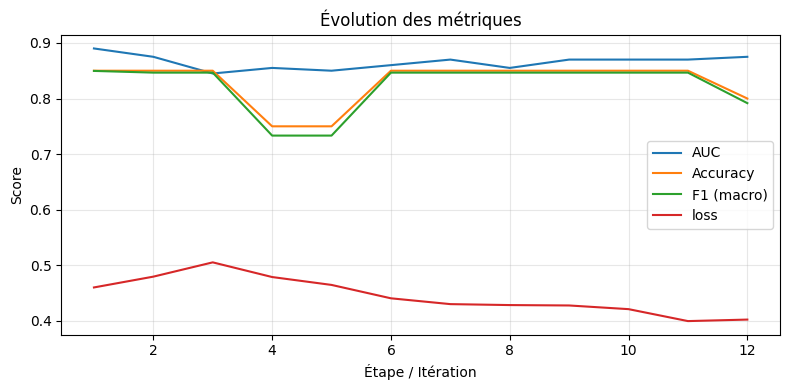

In [44]:
plot_metrics()

COURBE PRECISION-RECALL

precision_recall_curve attend shape (N,)  
model.predict() retourne shape (N, 1) avec sigmoid => utilisation de flatten

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


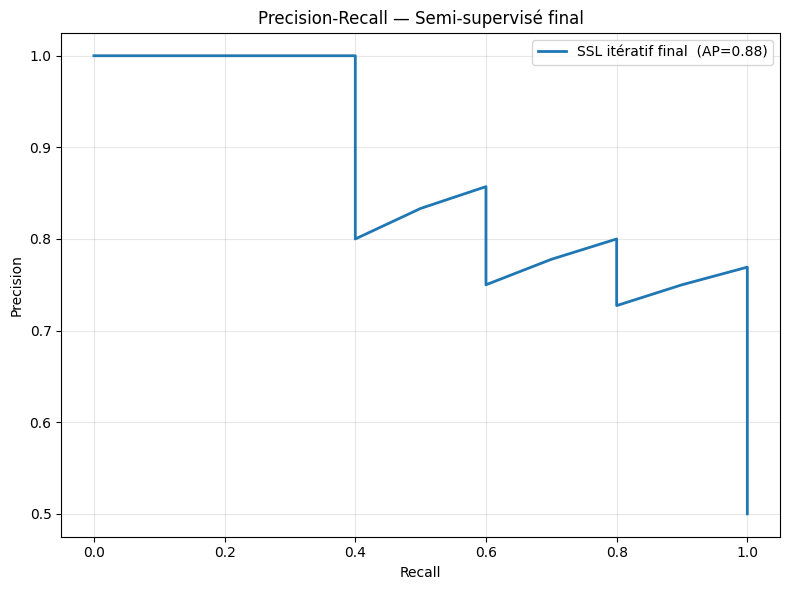

AP SSL itératif      : 0.8787


In [ ]:
y_proba_final = model_final.predict(X_test).flatten() # après itérations SSL

precision_final, recall_final, _ = precision_recall_curve(y_test, y_proba_final)

ap_final = average_precision_score(y_test, y_proba_final)

plt.figure(figsize=(8, 6))
plt.plot(recall_final, precision_final, label=f"SSL itératif final  (AP={ap_final:.2f})", linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall — Semi-supervisé final")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AP SSL itératif      : {ap_final:.4f}")

Matrice de confusion sur data train augmenté (vrais labels+ pseudo-labels)

9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step


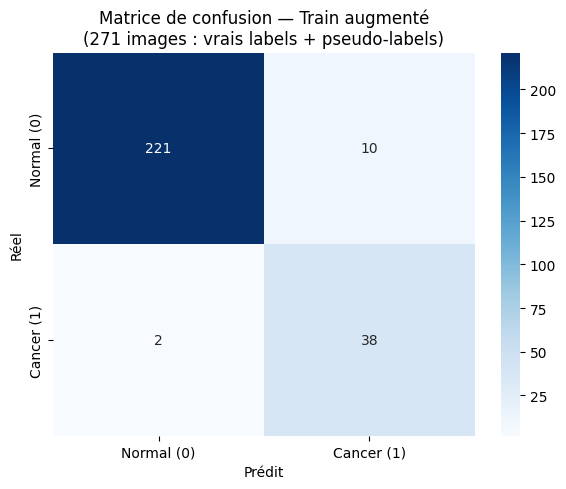

Vrais Négatifs  (TN) : 221  normaux bien détectés
Faux Positifs   (FP) : 10  normaux classés cancer
Faux Négatifs   (FN) : 2  cancers manqués
Vrais Positifs  (TP) : 38  cancers bien détectés


In [ ]:
# On garde uniquement les indices qui ont un label valide (vrais + pseudo-labels)
# y_full contient -1 pour les images encore unlabeled=> inutilisable
# -1 images jamais pseudo-labellisées= classe non valide (on a uniquement 0 et 1)
labeled_mask = y_full != -1 # booléen

X_train_final = X_full[labeled_mask] # images avec label valide
y_train_final = y_full[labeled_mask] # labels correspondants (0.0 ou 1.0)

# Prédictions sur le dataset final enrichi
y_proba_train = model_final.predict(X_train_final).flatten()
y_pred_train  = (y_proba_train > 0.5).astype(int)

cm_train = confusion_matrix(y_train_final, y_pred_train)

tn, fp, fn, tp = cm_train.ravel()

plt.figure(figsize=(6,5))
sns.heatmap(cm_train, annot=True, fmt="d",
            cmap="Blues",
            xticklabels=["Normal (0)", "Cancer (1)"],
            yticklabels=["Normal (0)", "Cancer (1)"])
plt.title(f"Matrice de confusion — Train augmenté\n({len(y_train_final)} images : vrais labels + pseudo-labels)")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.show()

print(f"Vrais Négatifs  (TN) : {tn}  normaux bien détectés")
print(f"Faux Positifs   (FP) : {fp}  normaux classés cancer")
print(f"Faux Négatifs   (FN) : {fn}  cancers manqués")
print(f"Vrais Positifs  (TP) : {tp}  cancers bien détectés")

Matrice de confusion finale sur test (vrais labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


Text(50.722222222222214, 0.5, 'Vrais labels')

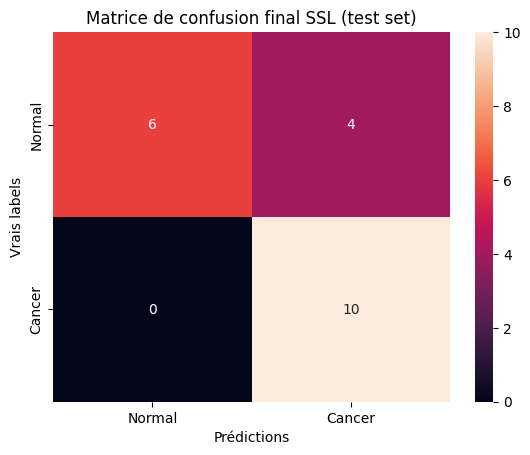

In [ ]:
y_proba_final = model_final.predict(X_test).flatten()
y_pred_final  = (y_proba_final > 0.5).astype(int)

cm_final = confusion_matrix(y_test, y_pred_final)

sns.heatmap(cm_final, annot=True, fmt="d",
            xticklabels=["Normal","Cancer"],
            yticklabels=["Normal","Cancer"])
plt.title("Matrice de confusion final SSL (test set)")
plt.xlabel("Prédictions")
plt.ylabel("Vrais labels")

In [48]:

tn, fp, fn, tp = cm_final.ravel()
print(f"Vrais Négatifs  (TN) : {tn}  normaux bien détectés")
print(f"Faux Positifs   (FP) : {fp}  normaux classés cancer")
print(f"Faux Négatifs   (FN) : {fn}  cancers manqués ")
print(f"Vrais Positifs  (TP) : {tp}  cancers bien détectés")

Vrais Négatifs  (TN) : 6  normaux bien détectés
Faux Positifs   (FP) : 4  normaux classés cancer
Faux Négatifs   (FN) : 0  cancers manqués 
Vrais Positifs  (TP) : 10  cancers bien détectés
